DATA CLEANING

Missing values before cleaning:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Missing values after cleaning:
embark_town    2
dtype: int64

✅ Dataset Shape: (891, 14)


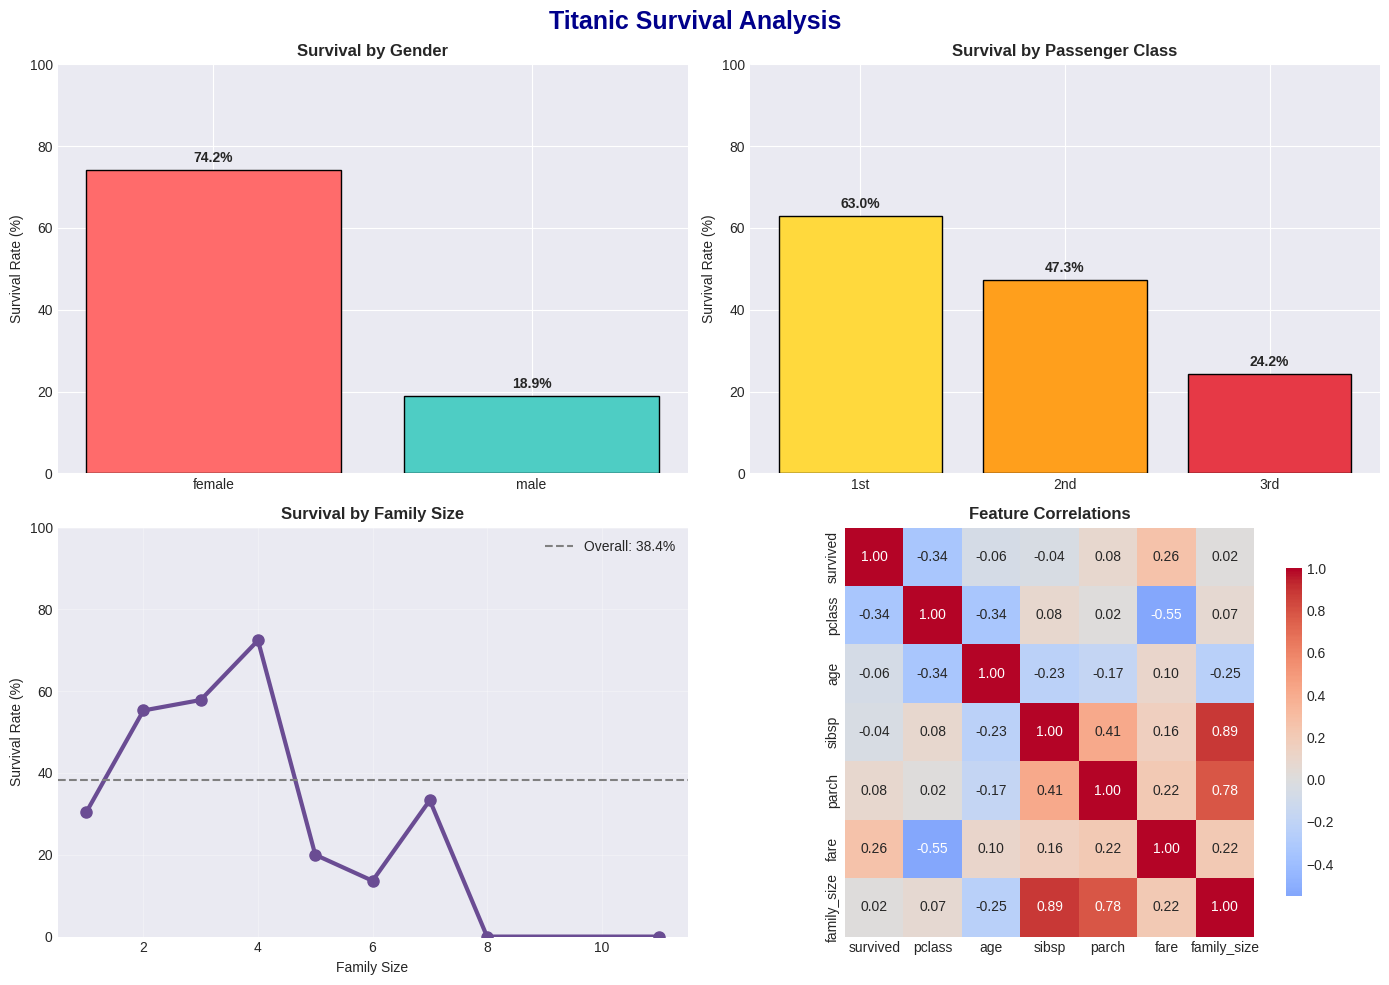


KEY FINDINGS

 Overall Survival Rate: 38.4%

 1 Gender Impact:
   Female Survival Rate : 74.2%
   Male Survival Rate   : 18.9%

 2  Passenger Class Impact:
   1st Class: 63.0%
   2nd Class: 47.3%
   3rd Class: 24.2%

 3  Survival by Age Group:
   Child: 58.0%
   Teen: 42.9%
   Adult: 36.3%
   Senior: 34.4%

 4 Family Size Impact:
   Best Family Size : 4 people
   Best Survival Rate : 72.4%
   Alone Passenger Survival : 30.4%

  EDA COMPLETE!
Women, higher-class passengers, and small families
had the highest survival rates on the Titanic.


In [62]:
# ============================================
# TITANIC DATA CLEANING & EDA - FINAL VERSION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset('titanic')

# ============================================
# DATA CLEANING
# ============================================

print("=" * 50)
print("DATA CLEANING")
print("=" * 50)

# Missing values before cleaning
print("\nMissing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing Age with median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing Embarked with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop Deck column
df.drop('deck', axis=1, inplace=True)

# Missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\n✅ Dataset Shape: {df.shape}")

# ============================================
# FEATURE ENGINEERING
# ============================================

# Create family size column
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 50, 100],
    labels=['Child', 'Teen', 'Adult', 'Senior']
)

# ============================================
# EDA VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Titanic Survival Analysis',
    fontsize=18,
    fontweight='bold',
    color='darkblue'
)

# ============================================
# 1. Survival by Gender
# ============================================

ax1 = axes[0, 0]

surv_sex = df.groupby('sex')['survived'].mean() * 100

bars1 = ax1.bar(
    surv_sex.index,
    surv_sex.values,
    color=['#FF6B6B', '#4ECDC4'],
    edgecolor='black'
)

ax1.set_title('Survival by Gender', fontweight='bold')
ax1.set_ylabel('Survival Rate (%)')
ax1.set_ylim(0, 100)

for bar in bars1:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height:.1f}%',
        ha='center',
        fontweight='bold'
    )

# ============================================
# 2. Survival by Passenger Class
# ============================================

ax2 = axes[0, 1]

surv_class = df.groupby('pclass')['survived'].mean() * 100

bars2 = ax2.bar(
    ['1st', '2nd', '3rd'],
    surv_class.values,
    color=['#FFD93D', '#FF9F1C', '#E63946'],
    edgecolor='black'
)

ax2.set_title('Survival by Passenger Class', fontweight='bold')
ax2.set_ylabel('Survival Rate (%)')
ax2.set_ylim(0, 100)

for bar in bars2:
    height = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height:.1f}%',
        ha='center',
        fontweight='bold'
    )

# ============================================
# 3. Survival by Family Size
# ============================================

ax3 = axes[1, 0]

family_surv = df.groupby('family_size')['survived'].mean() * 100

ax3.plot(
    family_surv.index,
    family_surv.values,
    marker='o',
    linewidth=3,
    markersize=8,
    color='#6A4C93'
)

ax3.set_title('Survival by Family Size', fontweight='bold')
ax3.set_xlabel('Family Size')
ax3.set_ylabel('Survival Rate (%)')
ax3.set_ylim(0, 100)

ax3.grid(True, alpha=0.3)

ax3.axhline(
    y=df['survived'].mean() * 100,
    color='gray',
    linestyle='--',
    label=f"Overall: {df['survived'].mean()*100:.1f}%"
)

ax3.legend()

# ============================================
# 4. Correlation Heatmap
# ============================================

ax4 = axes[1, 1]

corr_cols = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',
    'family_size'
]

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    ax=ax4,
    cbar_kws={'shrink': 0.8}
)

ax4.set_title('Feature Correlations', fontweight='bold')



plt.tight_layout()
plt.show()

# ============================================
# KEY FINDINGS
# ============================================

print("\n" + "=" * 50)
print("KEY FINDINGS")
print("=" * 50)

# Overall survival
overall_survival = df['survived'].mean() * 100

print(f"\n Overall Survival Rate: {overall_survival:.1f}%")

# Gender survival
female_survival = df[df['sex'] == 'female']['survived'].mean() * 100
male_survival = df[df['sex'] == 'male']['survived'].mean() * 100

print("\n 1 Gender Impact:")
print(f"   Female Survival Rate : {female_survival:.1f}%")
print(f"   Male Survival Rate   : {male_survival:.1f}%")

# Class survival
print("\n 2  Passenger Class Impact:")

for pclass in [1, 2, 3]:

    rate = df[df['pclass'] == pclass]['survived'].mean() * 100

    class_name = (
        "1st Class"
        if pclass == 1
        else "2nd Class"
        if pclass == 2
        else "3rd Class"
    )

    print(f"   {class_name}: {rate:.1f}%")

# Age groups
print("\n 3  Survival by Age Group:")

age_groups = df.groupby('age_group', observed=True)['survived'].mean() * 100

for group, rate in age_groups.items():
    print(f"   {group}: {rate:.1f}%")

# Family size
print("\n 4 Family Size Impact:")

best_family = family_surv.idxmax()
best_rate = family_surv.max()

alone_rate = df[df['family_size'] == 1]['survived'].mean() * 100

print(f"   Best Family Size : {best_family} people")
print(f"   Best Survival Rate : {best_rate:.1f}%")
print(f"   Alone Passenger Survival : {alone_rate:.1f}%")

print("\n" + "=" * 50)
print("  EDA COMPLETE!")
print("Women, higher-class passengers, and small families")
print("had the highest survival rates on the Titanic.")
print("=" * 50)